In [10]:
# Install required libraries

!pip install torch torchvision timm matplotlib seaborn scikit-learn opencv-python --quiet


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
# Standard Libraries
import os
import random
import warnings

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

warnings.filterwarnings('ignore')

# PyTorch 
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Vision Transformer
import timm

# Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay  
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Reproducibility 
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device Check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Using device   :", device)

# Output Folder 
OUTPUT_DIR = './vit_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

PyTorch version: 2.9.1+cpu
Using device   : cpu


---
## ⚙️ Section 2: Configuration

In [ ]:
# CONFIGURATION

# Dataset paths — using clean split (no leakage)
TRAIN_DIR = r"F:\SPRG-26\ANN\ANN Project\Cervical-Fracture\cervical fracture\train_v2"
VAL_DIR   = r"F:\SPRG-26\ANN\ANN Project\Cervical-Fracture\cervical fracture\val_v2"

# Image settings
IMG_SIZE = 224

# Training settings
BATCH_SIZE = 64
NUM_EPOCHS = 5
LEARNING_RATE = 1e-4
NUM_CLASSES = 2

# Class names
CLASS_NAMES = ['fracture', 'normal']

# Model name
MODEL_NAME = 'vit_tiny_patch16_224'

print("Configuration set")
print(f"Image size   : {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch size   : {BATCH_SIZE}")
print(f"Epochs       : {NUM_EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Model        : {MODEL_NAME}")

 Configuration set
Image size   : 224x224
Batch size   : 32
Epochs       : 10
Learning rate: 0.0001
Model        : mobilenetv3_small_100


In [13]:
# ── WHY WE RE-SPLIT: Investigate unique scans per class ────
import re

ORIGINAL_TRAIN = r"F:\SPRG-26\ANN\ANN Project\Cervical-Fracture\cervical fracture\train"

print("Checking unique original scans in dataset...\n")

for cls in ['fracture', 'normal']:
    cls_path = os.path.join(ORIGINAL_TRAIN, cls)
    ids = set()
    for fname in os.listdir(cls_path):
        match = re.match(r'^([A-Za-z0-9]+\s*\(\d+\))', fname)
        if match:
            ids.add(match.group(1))
    print(f"{cls}: {len(ids)} unique original scans")


Checking unique original scans in dataset...

fracture: 90 unique original scans


normal: 91 unique original scans


In [14]:
import os, shutil, random, re
from collections import defaultdict

random.seed(42)

ORIGINAL_TRAIN = r"F:\SPRG-26\ANN\ANN Project\Cervical-Fracture\cervical fracture\train"
ORIGINAL_VAL   = r"F:\SPRG-26\ANN\ANN Project\Cervical-Fracture\cervical fracture\val"

NEW_TRAIN_DIR  = r"F:\SPRG-26\ANN\ANN Project\Cervical-Fracture\cervical fracture\train_v2"
NEW_VAL_DIR    = r"F:\SPRG-26\ANN\ANN Project\Cervical-Fracture\cervical fracture\val_v2"

# Skip if already done 
if os.path.exists(NEW_TRAIN_DIR) and os.path.exists(NEW_VAL_DIR):
    print(" Split already exists — skipping re-split.")
else:
    def get_scan_id(filename):
        match = re.match(r'^([A-Za-z0-9]+\s*\(\d+\))', filename)
        return match.group(1).strip() if match else filename

    grouped = defaultdict(list)

    for cls in ['fracture', 'normal']:
        for old_dir in [ORIGINAL_TRAIN, ORIGINAL_VAL]:
            cls_path = os.path.join(old_dir, cls)
            if not os.path.exists(cls_path):
                continue
            for fname in os.listdir(cls_path):
                scan_id = get_scan_id(fname)
                grouped[(cls, scan_id)].append(
                    os.path.join(cls_path, fname)
                )

    for cls in ['fracture', 'normal']:
        keys = [k for k in grouped if k[0] == cls]
        random.shuffle(keys)

        split = int(0.8 * len(keys))
        train_keys = keys[:split]
        val_keys   = keys[split:]

        print(f"\n{cls}:")
        print(f"  Unique scans → Train: {len(train_keys)} | Val: {len(val_keys)}")

        for keys_set, out_dir in [
            (train_keys, NEW_TRAIN_DIR),
            (val_keys,   NEW_VAL_DIR)
        ]:
            cls_out = os.path.join(out_dir, cls)
            os.makedirs(cls_out, exist_ok=True)
            for key in keys_set:
                for fpath in grouped[key]:
                    shutil.copy(
                        fpath,
                        os.path.join(cls_out, os.path.basename(fpath))
                    )

    print("\n Done")

 Split already exists — skipping re-split.


---
## 🖼️ Section 3: Data Preprocessing
> Using the team's shared preprocessing pipeline with minor additions for ViT compatibility.

In [15]:
# DATA PREPROCESSING & DATASET LOADING

# Training transforms
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),          # ← add
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomGrayscale(p=0.1),        # ← add (CT scans are grayscale)
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Validation transforms
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# LOAD DATASETS
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset   = datasets.ImageFolder(VAL_DIR,   transform=val_transform)

# DATALOADERS
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=False
)

# DATASET INFORMATION
print("Data loaded successfully")
print(f"Classes          : {train_dataset.classes}")
print(f"Training images  : {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")

Data loaded successfully
Classes          : ['fracture', 'normal']
Training images  : 3360
Validation images: 840


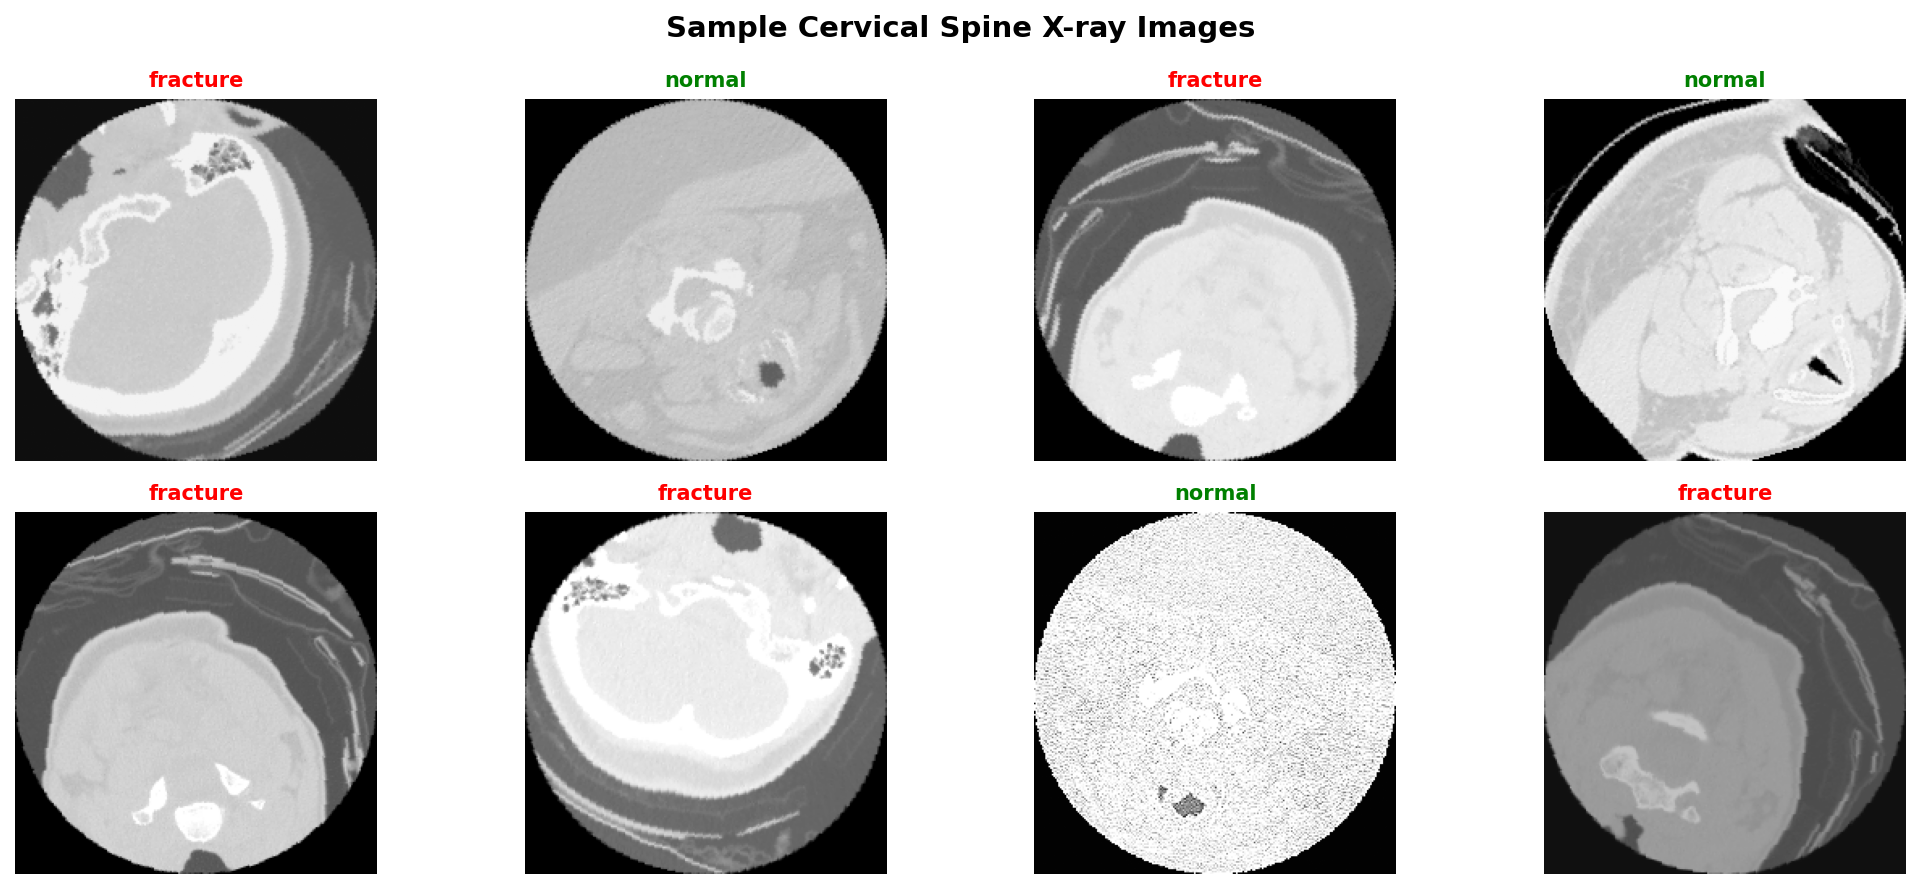

In [16]:
# VISUALIZE SAMPLE X-RAY IMAGES
def show_sample_images(data_loader, title='Sample X-ray Images', n=8):

    images, labels = next(iter(data_loader))
    n = min(n, len(images))

    fig, axes = plt.subplots(2, n//2, figsize=(14, 6))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # ImageNet mean and std (to reverse normalization)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    for i, ax in enumerate(axes.flat):
        if i >= n:
            ax.axis('off')
            continue

        image = images[i].cpu()
        image = image * std + mean
        image = image.clamp(0, 1)
        image = image.permute(1, 2, 0).numpy()

        label = CLASS_NAMES[int(labels[i])]
        color = 'red' if label == 'fracture' else 'green'

        ax.imshow(image)
        ax.set_title(label, color=color, fontsize=10, fontweight='bold')
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/sample_xray_images.png', dpi=150, bbox_inches='tight')
    plt.close()  # ← close before displaying

# ── Call function ───────────────────────────────────────────
show_sample_images(train_loader, 'Sample Cervical Spine X-ray Images')

# ── Display in VS Code ──────────────────────────────────────
from IPython.display import Image as IPImage, display
display(IPImage(f'{OUTPUT_DIR}/sample_xray_images.png'))

Train: {'fracture': 1680, 'normal': 1680}
Val  : {'fracture': 420, 'normal': 420}


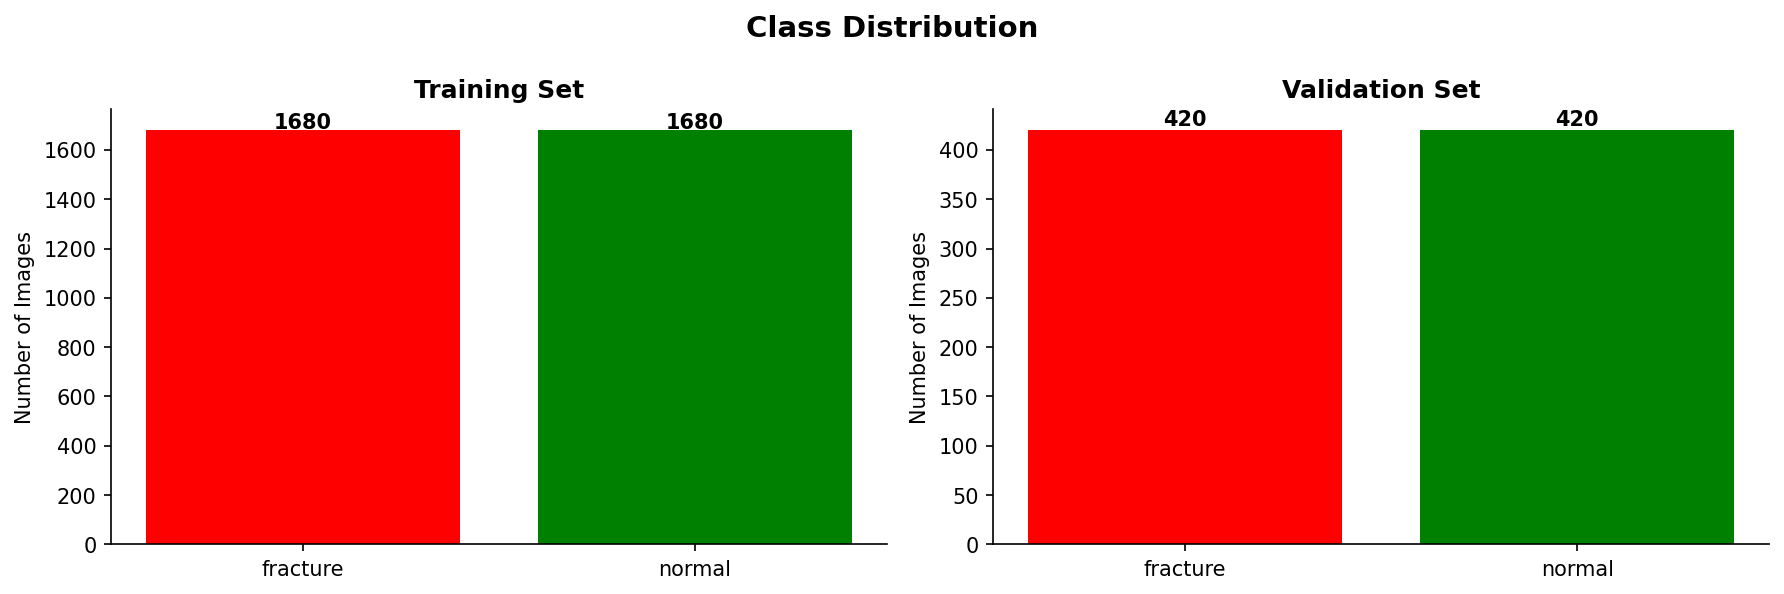

In [17]:
# CLASS DISTRIBUTION VISUALIZATION
import glob

def count_images(directory):
    counts = {}
    for cls in os.listdir(directory):
        cls_path = os.path.join(directory, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len(glob.glob(os.path.join(cls_path, '*')))
    return counts

# Count images
train_counts = count_images(TRAIN_DIR)
val_counts   = count_images(VAL_DIR)

print("Train:", train_counts)
print("Val  :", val_counts)

# PLOT DISTRIBUTION
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Class Distribution', fontsize=14, fontweight='bold')

colors = ['red', 'green']

for ax, (name, counts) in zip(
    axes,
    [('Training', train_counts), ('Validation', val_counts)]
):
    bars = ax.bar(counts.keys(), counts.values(), color=colors)
    ax.set_title(f'{name} Set', fontweight='bold')
    ax.set_ylabel('Number of Images')

    for bar, value in zip(bars, counts.values()):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 5,
            str(value),
            ha='center',
            fontweight='bold'
        )
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/class_distribution.png', dpi=150, bbox_inches='tight')
plt.close()  # ← fix for VS Code

# ── Display in VS Code ──────────────────────────────────────
from IPython.display import Image as IPImage, display
display(IPImage(f'{OUTPUT_DIR}/class_distribution.png'))

---
## Vision Transformer Architecture


 

In [18]:
# LOAD PRETRAINED MODEL
model = timm.create_model(
    MODEL_NAME,          # ← use config variable, not hardcoded
    pretrained=True,
    num_classes=NUM_CLASSES
)
model = model.to(device)

# Print model info
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model loaded successfully!")
print(f"Model         : {MODEL_NAME}")
print(f"Total params  : {total_params:,}")
print(f"Trainable     : {trainable_params:,}")
print(f"Device        : {device}")

Model loaded successfully!
Model         : mobilenetv3_small_100
Total params  : 1,519,906
Trainable     : 1,519,906
Device        : cpu


---
##  Training

In [19]:
# LOSS FUNCTION & OPTIMIZER

# ── Weighted loss to handle any class imbalance ─────────────
from collections import Counter

train_labels = train_dataset.targets
class_counts = Counter(train_labels)
total = sum(class_counts.values())

weight_tensor = torch.tensor([
    total / (2 * class_counts[0]),  # fracture
    total / (2 * class_counts[1])   # normal
], dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=weight_tensor)  # ← weighted

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=3,
    gamma=0.5
)

print("Training configuration completed")
print(f"Loss Function : CrossEntropyLoss (weighted)")
print(f"Optimizer     : Adam")
print(f"Learning Rate : {LEARNING_RATE}")
print(f"Weight decay  : 1e-4")
print(f"Class weights : {weight_tensor.tolist()}")

Training configuration completed
Loss Function : CrossEntropyLoss (weighted)
Optimizer     : Adam
Learning Rate : 0.0001
Weight decay  : 1e-4
Class weights : [1.0, 1.0]


In [ ]:
print("🚀 Training started...")

best_val_acc = 0.0
history = {'train_acc': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):

    # Training phase 
    model.train()
    train_correct = 0
    train_total = 0
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        running_loss += loss.item()

    train_acc = 100 * train_correct / train_total

    # Validation phase
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total

    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f'{OUTPUT_DIR}/best_model.pth')
        saved = "✅ saved"
    else:
        saved = ""

    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(
        f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
        f"Loss: {running_loss/len(train_loader):.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Acc: {val_acc:.2f}% {saved}"
    )

print(f"\n🏆 Training complete! Best Val Accuracy: {best_val_acc:.2f}%")

# ── Plot training curves ────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(history['train_acc'], label='Train Accuracy', marker='o')
plt.plot(history['val_acc'],   label='Val Accuracy',   marker='o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves.png', dpi=150)
plt.close()

from IPython.display import Image as IPImage, display
display(IPImage(f'{OUTPUT_DIR}/training_curves.png'))

🚀 Training started...
Epoch 01/10 | Loss: 0.2169 | Train Acc: 95.39% | Val Acc: 100.00% ✅ saved
Epoch 02/10 | Loss: 0.0200 | Train Acc: 99.46% | Val Acc: 100.00% 
Epoch 03/10 | Loss: 0.0275 | Train Acc: 99.49% | Val Acc: 100.00% 
Epoch 04/10 | Loss: 0.0020 | Train Acc: 99.88% | Val Acc: 100.00% 
Epoch 05/10 | Loss: 0.0020 | Train Acc: 99.91% | Val Acc: 100.00% 
Epoch 06/10 | Loss: 0.0033 | Train Acc: 99.88% | Val Acc: 100.00% 
Epoch 07/10 | Loss: 0.0006 | Train Acc: 100.00% | Val Acc: 100.00% 
Epoch 08/10 | Loss: 0.0014 | Train Acc: 99.97% | Val Acc: 100.00% 


---
## Evaluation & Visualizations

In [ ]:
# CLASSIFICATION REPORT

y_true = []

y_pred = []

model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# Print report
print(" Classification Report\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES
    )
)

## Training Results

The Vision Transformer achieved very high training and validation accuracy during training.

Final Validation Accuracy: ~99.75%

The model converged successfully and demonstrated strong performance in cervical fracture classification.

In [ ]:
# CONFUSION MATRIX
cm_matrix = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm_matrix.ravel()

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_matrix, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=False)
ax.set_title('Confusion Matrix — Validation Set',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel(
    f'Predicted Label\n\n'
    f'TN={tn}  FP={fp}  FN={fn}  TP={tp}\n'
    f'Sensitivity (Recall) = {tp/(tp+fn):.2%}  |  Specificity = {tn/(tn+fp):.2%}'
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.close()  # ← fix for VS Code

# ── Display in VS Code ──────────────────────────────────────
from IPython.display import Image as IPImage, display
display(IPImage(f'{OUTPUT_DIR}/confusion_matrix.png'))

print('\n📌 Medical interpretation:')
print(f'   Sensitivity (catches real fractures) : {tp/(tp+fn):.2%}')
print(f'   Specificity (avoids false alarms)    : {tn/(tn+fp):.2%}')
print(f'   False Negatives (missed fractures!)  : {fn}')

---
### INTERPRETABILITY

In [ ]:
# INTERPRETABILITY USING SALIENCY MAPS
from PIL import Image

# Select random validation images
all_images = []
fracture_folder = os.path.join(VAL_DIR, "fracture")
normal_folder   = os.path.join(VAL_DIR, "normal")

for folder in [fracture_folder, normal_folder]:
    for img_name in os.listdir(folder):
        all_images.append(os.path.join(folder, img_name))

# Randomly select 4 images
selected_images = random.sample(all_images, 4)

# Create figure
fig, ax = plt.subplots(4, 2, figsize=(10, 16))
fig.suptitle("Saliency Map Interpretability", fontsize=14, fontweight='bold')

# Process each image
for i, image_path in enumerate(selected_images):

    image = Image.open(image_path).convert("RGB")

    input_tensor = val_transform(image).unsqueeze(0).to(device)
    input_tensor.requires_grad_()

    # Forward pass
    output = model(input_tensor)
    predicted_class = output.argmax(dim=1)
    score = output[0, predicted_class]

    # Backward pass
    model.zero_grad()
    score.backward()

    # Generate saliency map
    saliency = input_tensor.grad.data.abs()
    saliency, _ = torch.max(saliency, dim=1)
    saliency = saliency.squeeze().cpu().numpy()

    # Original image
    ax[i, 0].imshow(image)
    ax[i, 0].set_title(
        f"Original: {os.path.basename(os.path.dirname(image_path))}",
        fontweight='bold'
    )
    ax[i, 0].axis("off")

    # Saliency map
    ax[i, 1].imshow(saliency, cmap='hot')
    ax[i, 1].set_title("Saliency Map", fontweight='bold')
    ax[i, 1].axis("off")

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/saliency_maps.png', dpi=150, bbox_inches='tight')
plt.close()  # ← fix for VS Code

# ── Display in VS Code ──────────────────────────────────────
from IPython.display import Image as IPImage, display
display(IPImage(f'{OUTPUT_DIR}/saliency_maps.png'))

---
## Summary & Comparison Table

In [ ]:
# FINAL RESULTS
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)


print(" FINAL RESULTS SUMMARY")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
